In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIG
DATA_PATH = "../data/Sleep_health_and_lifestyle_dataset.csv"

# LOAD
df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.dtypes)
print(df.head())

(374, 13)
Person ID                    int64
Gender                         str
Age                          int64
Occupation                     str
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                   str
Blood Pressure                 str
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder                 str
dtype: object
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42     

In [50]:
print(df['Sleep Disorder'].value_counts(dropna=False))
print(df['BMI Category'].value_counts())
print(df['Occupation'].value_counts())
print(df.isnull().sum())

Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64
BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [51]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

low_freq = ['Software Engineer', 'Scientist', 'Sales Representative', 'Manager']
df['Occupation'] = df['Occupation'].replace(low_freq, 'Other')

print(df['Sleep Disorder'].value_counts())
print(df['BMI Category'].value_counts())
print(df['Occupation'].value_counts())

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64
BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64
Occupation
Nurse          73
Doctor         71
Engineer       63
Lawyer         47
Teacher        40
Accountant     37
Salesperson    32
Other          11
Name: count, dtype: int64


In [52]:
# SPLIT BLOOD PRESSURE
df[['BP Systolic', 'BP Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df = df.drop(columns=['Blood Pressure'])

print(df[['BP Systolic', 'BP Diastolic']].describe())

       BP Systolic  BP Diastolic
count   374.000000    374.000000
mean    128.553476     84.649733
std       7.748118      6.161611
min     115.000000     75.000000
25%     125.000000     80.000000
50%     130.000000     85.000000
75%     135.000000     90.000000
max     142.000000     95.000000


In [53]:
df = df.drop(columns=['Person ID'])

print(df.shape)
print(df.columns.tolist())

(374, 13)
['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Sleep Disorder', 'BP Systolic', 'BP Diastolic']


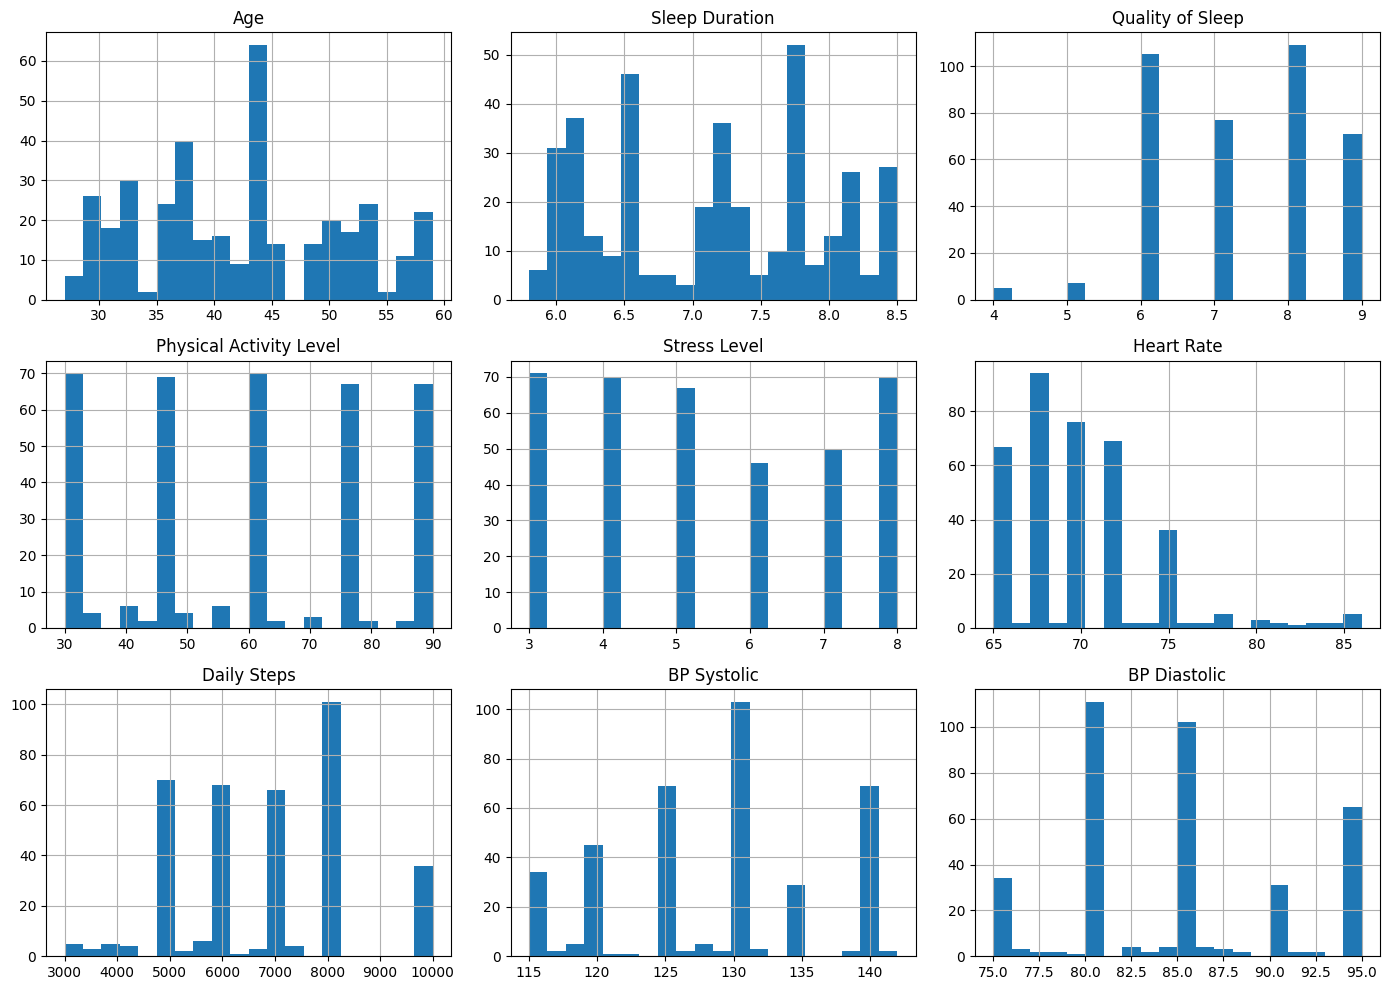

In [54]:
NUMERICAL = [
    'Age', 'Sleep Duration', 'Quality of Sleep',
    'Physical Activity Level', 'Stress Level',
    'Heart Rate', 'Daily Steps', 'BP Systolic', 'BP Diastolic'
]

df[NUMERICAL].hist(bins=20, figsize=(14, 10))
plt.tight_layout()
plt.savefig('../notebooks/numerical_distributions.png', dpi=150)
plt.show()

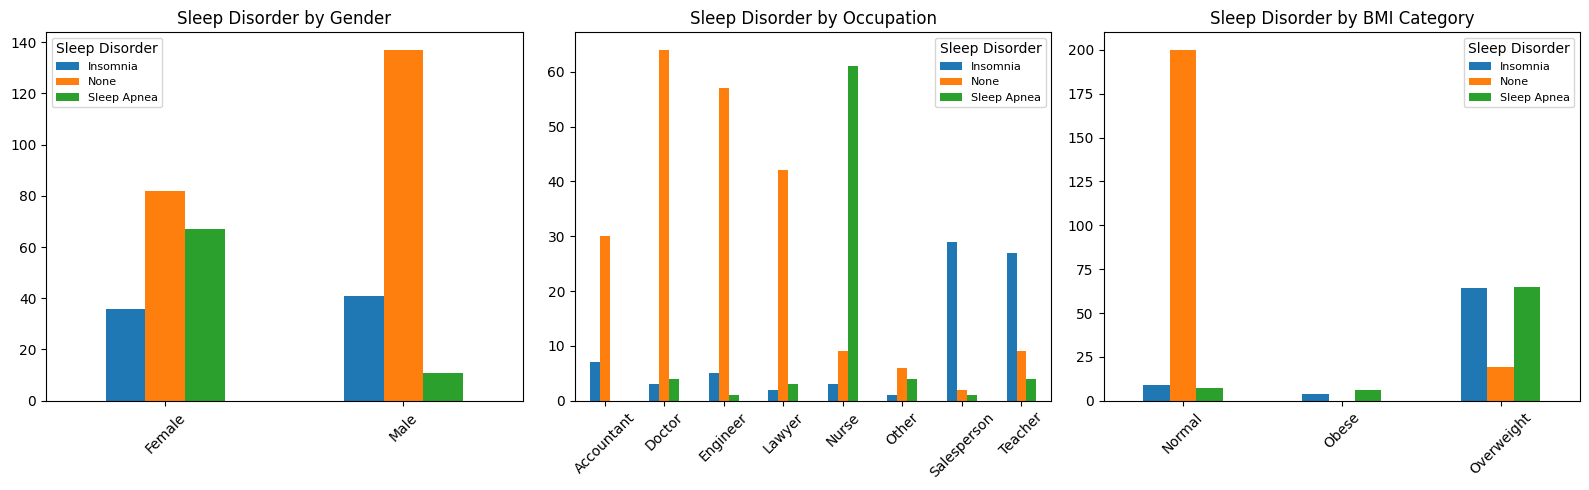

In [55]:
CATEGORICAL = ['Gender', 'Occupation', 'BMI Category']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, CATEGORICAL):
    disorder_counts = df.groupby([col, 'Sleep Disorder']).size().unstack(fill_value=0)
    disorder_counts.plot(kind='bar', ax=ax, rot=45)
    ax.set_title(f'Sleep Disorder by {col}')
    ax.set_xlabel('')
    ax.legend(title='Sleep Disorder', fontsize=8)

plt.tight_layout()
plt.savefig('../notebooks/categorical_vs_target.png', dpi=150)
plt.show()

In [56]:
print(df.groupby('Gender')['Sleep Disorder'].value_counts(normalize=True).round(2))

Gender  Sleep Disorder
Female  None              0.44
        Sleep Apnea       0.36
        Insomnia          0.19
Male    None              0.72
        Insomnia          0.22
        Sleep Apnea       0.06
Name: proportion, dtype: float64


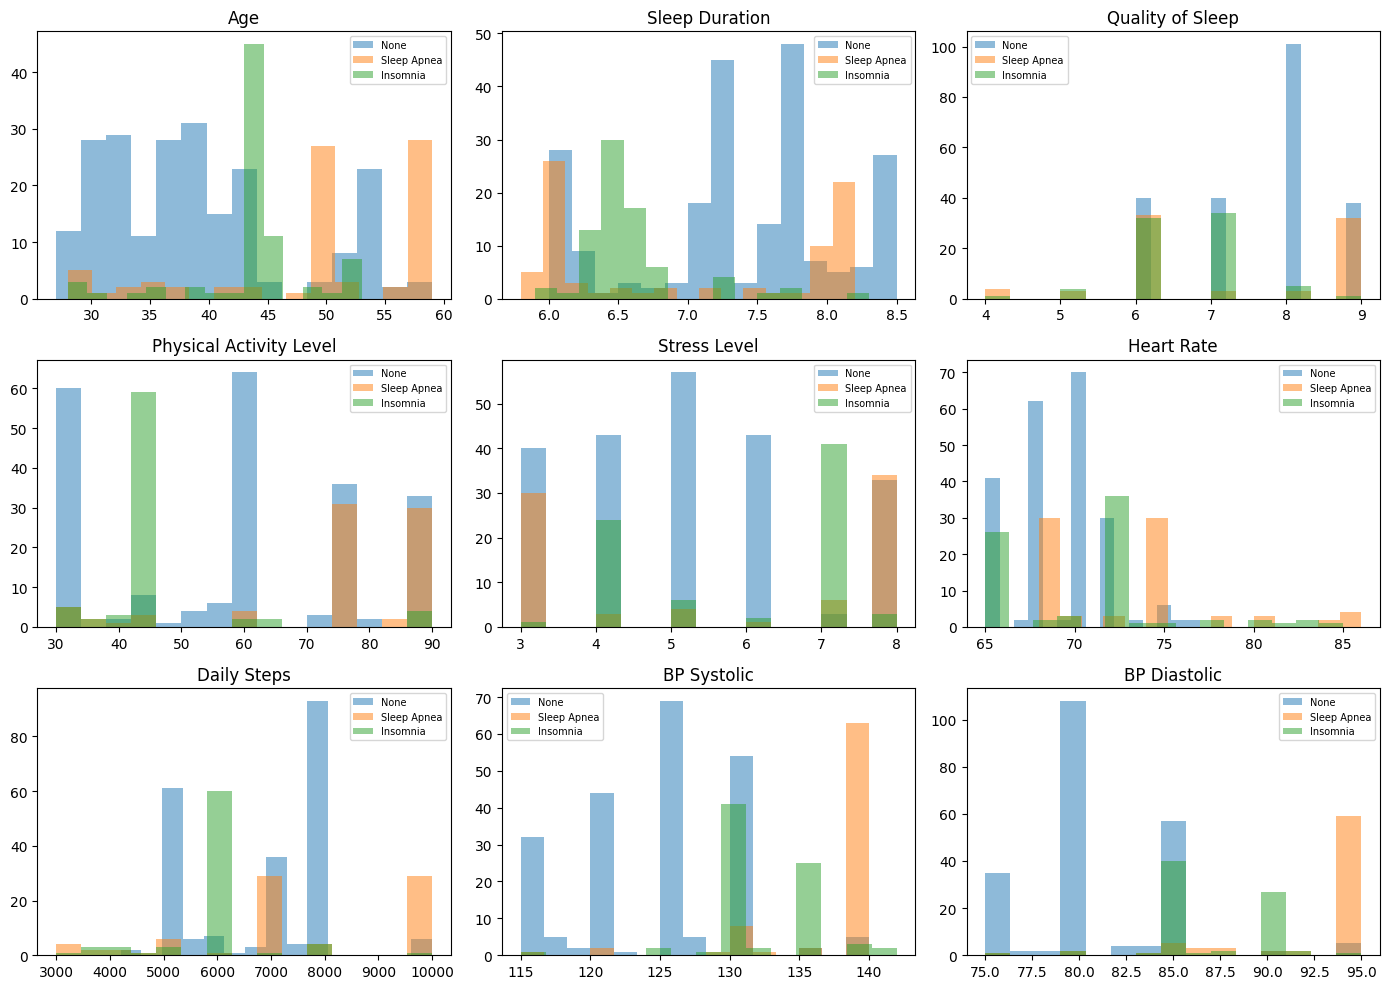

In [57]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL):
    for disorder in df['Sleep Disorder'].unique():
        subset = df[df['Sleep Disorder'] == disorder][col]
        axes[i].hist(subset, bins=15, alpha=0.5, label=disorder)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.savefig('../notebooks/numerical_vs_target.png', dpi=150)
plt.show()

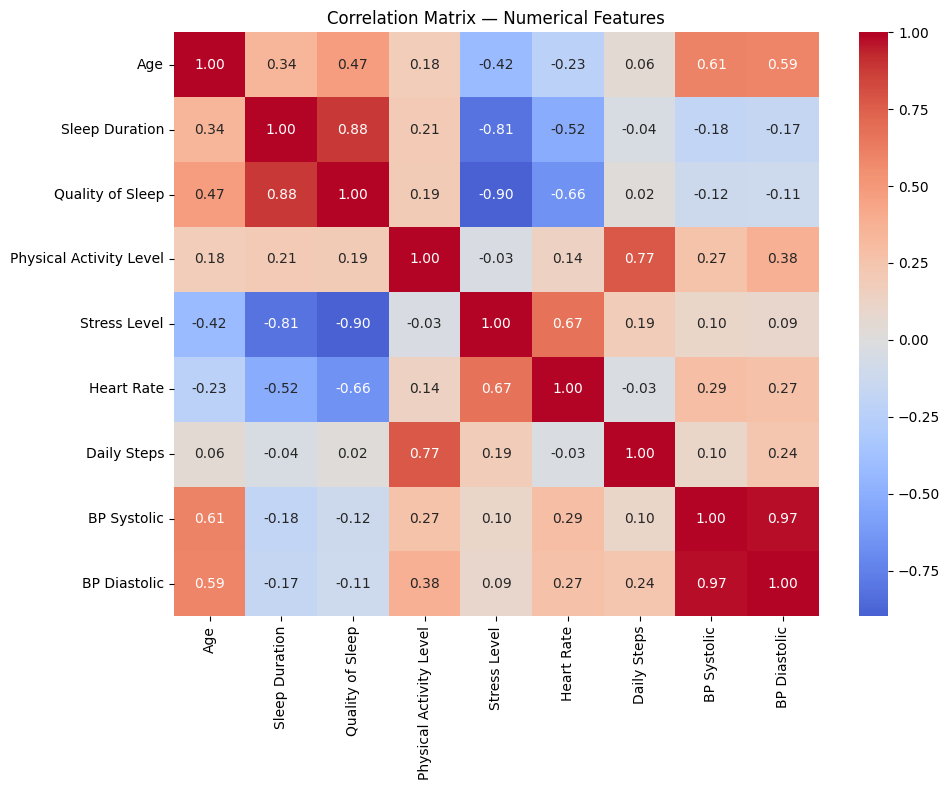

In [58]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = df[NUMERICAL].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax)
ax.set_title('Correlation Matrix — Numerical Features')

plt.tight_layout()
plt.savefig('../notebooks/correlation_matrix.png', dpi=150)
plt.show()

In [59]:
df['Pulse Pressure'] = df['BP Systolic'] - df['BP Diastolic']
df = df.drop(columns=['BP Systolic', 'BP Diastolic'])

print(df['Pulse Pressure'].describe())
print(df.shape)

count    374.000000
mean      43.903743
std        2.259644
min       37.000000
25%       43.000000
50%       45.000000
75%       45.000000
max       50.000000
Name: Pulse Pressure, dtype: float64
(374, 12)
